# 05 — Shapelet score vs moment score

Produces `fig/score_comparison.pdf` (`fig:comparison`): the shapelet score against the
third-order moment score, matched per (visit, raft), for the DP2 epoch which has the
per-raft moment catalog.

The two metrics measure the same physical thing (odd-$m$ / asymmetric PSF structure) by
completely different routes, so their agreement validates both. We report Spearman rank
correlation as the headline number because both distributions are heavy-tailed.

In [1]:
import importlib.util
spec = importlib.util.spec_from_file_location('plot_config', 'plot_config.py')
plot_config = importlib.util.module_from_spec(spec); spec.loader.exec_module(plot_config)
from plot_config import (BANDS, BAND_COLORS, PALETTE, FIG, DATA, SCIENCE_RAFTS,
                         MultipleLocator, apply_style, bvec_path, shapelet_score,
                         moment_score, THIRD_ORDER, detector_to_raft)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import spearmanr

apply_style()
TAG = 'dp2all'

## Build the per-(visit, raft, band) matched table

In [2]:
det2raft = detector_to_raft()          # stack-free: raft = SCIENCE_RAFTS[det // 9]

shap = []
for band in BANDS:
    d = np.load(bvec_path(band, TAG))
    shap.append(pd.DataFrame(dict(
        visit_id=d['visit'].astype(np.int64),
        raft=[det2raft.get(int(x), 'unknown') for x in d['detector']],
        band=band,
        s_shapelet=shapelet_score(d['bvec']),
        s_n3=shapelet_score(d['bvec'], THIRD_ORDER))))
shap = pd.concat(shap, ignore_index=True)
shap = shap[shap.raft.isin(SCIENCE_RAFTS)]
shap = shap.groupby(['visit_id', 'raft', 'band'], as_index=False).median(numeric_only=True)
print(f'shapelet rows: {len(shap):,}')

shapelet rows: 612,511


In [3]:
cols = ['visit_id', 'band'] + [f'{c}_{r}' for r in SCIENCE_RAFTS
                               for c in ('c11', 'c12', 'c31', 'c32')]
mom = pd.read_parquet(DATA / 'psf_moments_allbands.pq', columns=cols)
long = []
for r in SCIENCE_RAFTS:
    sub = mom[['visit_id', 'band', f'c11_{r}', f'c12_{r}', f'c31_{r}', f'c32_{r}']].copy()
    sub.columns = ['visit_id', 'band', 'c11', 'c12', 'c31', 'c32']
    sub['raft'] = r
    long.append(sub)
long = pd.concat(long, ignore_index=True).dropna()
long['s_moment'] = moment_score(long.c11, long.c12, long.c31, long.c32)
print(f'moment rows: {len(long):,}')

df = shap.merge(long[['visit_id', 'raft', 'band', 's_moment']],
                on=['visit_id', 'raft', 'band'], how='inner')
df = df[(df.s_shapelet > 0) & (df.s_moment > 0)]
print(f'matched (visit, raft, band) rows: {len(df):,}')

moment rows: 607,959


matched (visit, raft, band) rows: 607,948


In [4]:
def report(x, y, label):
    rho = spearmanr(x, y).statistic
    r_log = np.corrcoef(np.log10(x), np.log10(y))[0, 1]
    print(f'{label:>28}: spearman rho = {rho:+.3f}   pearson r (log-log) = {r_log:+.3f}'
          f'   N = {len(x):,}')
    return rho, r_log

print('--- all bands pooled ---')
rho_all, rlog_all = report(df.s_shapelet, df.s_moment, 'full score (n=3,5)')
report(df.s_n3, df.s_moment, 'n=3 only vs moment')

print('\n--- per band ---')
per_band = {}
for band in BANDS:
    sub = df[df.band == band]
    per_band[band] = report(sub.s_shapelet, sub.s_moment, f'band {band}')

--- all bands pooled ---
          full score (n=3,5): spearman rho = +0.923   pearson r (log-log) = +0.923   N = 607,948


          n=3 only vs moment: spearman rho = +0.933   pearson r (log-log) = +0.932   N = 607,948

--- per band ---
                      band u: spearman rho = +0.936   pearson r (log-log) = +0.937   N = 42,518
                      band g: spearman rho = +0.919   pearson r (log-log) = +0.917   N = 88,296
                      band r: spearman rho = +0.908   pearson r (log-log) = +0.914   N = 102,823
                      band i: spearman rho = +0.930   pearson r (log-log) = +0.929   N = 163,475


                      band z: spearman rho = +0.912   pearson r (log-log) = +0.911   N = 120,748
                      band y: spearman rho = +0.932   pearson r (log-log) = +0.928   N = 90,088


## Figure

wrote /sdf/data/rubin/user/ztq1996/psf-rubin/psf_zernike/shapelet_score_paper/fig/score_comparison.pdf


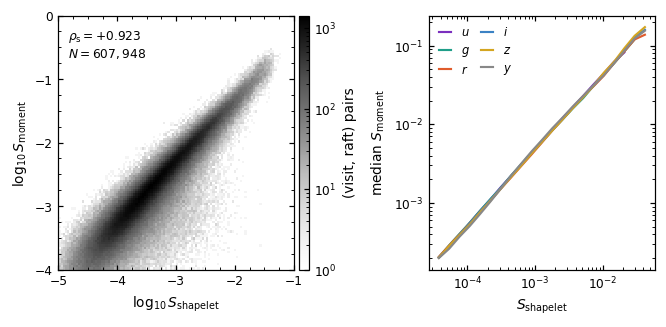

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0),
                         gridspec_kw=dict(wspace=0.34, width_ratios=[1.25, 1]))

# -- left: 2D histogram, all bands pooled, log-log ---------------------------
ax = axes[0]
xr, yr = (1e-5, 1e-1), (1e-4, 1e0)
h = ax.hist2d(np.log10(df.s_shapelet), np.log10(df.s_moment), bins=(110, 110),
              range=(np.log10(xr), np.log10(yr)), norm=LogNorm(), cmap='Greys')
ax.set_xlabel(r'$\log_{10} S_{\rm shapelet}$')
ax.set_ylabel(r'$\log_{10} S_{\rm moment}$')
ax.xaxis.set_minor_locator(MultipleLocator(0.25))
ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.yaxis.set_minor_locator(MultipleLocator(0.25))
ax.yaxis.set_major_locator(MultipleLocator(1.0))
ax.text(0.04, 0.95, rf'$\rho_{{\rm s}} = {rho_all:+.3f}$' '\n' rf'$N = {len(df):,}$',
        transform=ax.transAxes, va='top', fontsize=8)
fig.colorbar(h[3], ax=ax, label='(visit, raft) pairs', pad=0.02, aspect=26)

# -- right: median relation per band -----------------------------------------
ax = axes[1]
edges = np.logspace(-4.5, -1.3, 22)
mid = np.sqrt(edges[:-1] * edges[1:])
for band in BANDS:
    sub = df[df.band == band]
    med = np.array([np.median(sub.s_moment[(sub.s_shapelet >= a) & (sub.s_shapelet < b)])
                    if ((sub.s_shapelet >= a) & (sub.s_shapelet < b)).sum() > 30 else np.nan
                    for a, b in zip(edges[:-1], edges[1:])])
    ax.plot(mid, med, color=BAND_COLORS[band], lw=1.4, label=f'${band}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$S_{\rm shapelet}$')
ax.set_ylabel(r'median $S_{\rm moment}$')
ax.legend(ncol=2, frameon=False, fontsize=7.5, loc='upper left',
          handlelength=1.1, columnspacing=1.0)

fig.savefig(FIG / 'score_comparison.pdf')
print('wrote', FIG / 'score_comparison.pdf')

In [6]:
# Power-law slope of the median relation, S_moment ~ S_shapelet^alpha.
lx, ly = np.log10(df.s_shapelet.values), np.log10(df.s_moment.values)
sel = (lx > -4.5) & (lx < -1.5)
alpha, beta = np.polyfit(lx[sel], ly[sel], 1)
print(f'S_moment ~ S_shapelet^{alpha:.2f}  (intercept {beta:+.2f}, fit over '
      f'10^-4.5 < S_sh < 10^-1.5, N={sel.sum():,})')

# Scatter about the fitted relation
resid = ly[sel] - (alpha * lx[sel] + beta)
print(f'scatter about the relation: {np.std(resid):.3f} dex '
      f'(16-84%: {np.percentile(resid,16):+.3f} to {np.percentile(resid,84):+.3f})')

print()
print('LaTeX row of per-band Spearman rho:')
print(' & '.join(f'${b}$' for b in BANDS) + r' \\')
print(' & '.join(f'{per_band[b][0]:+.3f}' for b in BANDS) + r' \\')

S_moment ~ S_shapelet^0.95  (intercept +0.50, fit over 10^-4.5 < S_sh < 10^-1.5, N=589,790)
scatter about the relation: 0.240 dex (16-84%: -0.167 to +0.181)

LaTeX row of per-band Spearman rho:
$u$ & $g$ & $r$ & $i$ & $z$ & $y$ \\
+0.936 & +0.919 & +0.908 & +0.930 & +0.912 & +0.932 \\
